# AutoEncoder on Lower Triangular Flattened Matrix of Correlation Matrices
In this notebook we train an AutoEncoder (with non-linear activations) on full correlation matrices, compress them into a latent space, reconstruct them, and evaluate reconstruction quality across different latent dimensions.

In [1]:
from pathlib import Path
import random
import warnings
import sys
import json

import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True, precision=4)
warnings.filterwarnings('ignore', message='.*Clustering large matrix.*')

## Step 1: Load Train/Val/Test Splits
Load correlation matrices and their Cholesky factors from an existing dataset folder containing `train.pt`, `val.pt`, and `test.pt` (each must include `cholesky_L`).
- Local PC: `data/processed/dataset/<DATASET_NAME>`
- Google Colab: `dataset_tesi/<DATASET_NAME>`

In [2]:
FILE_NAME = 'data_00_20'
WINDOW_SIZE = 724
STEP_SIZE = 10
DATASET_NAME = f'{FILE_NAME}_w{WINDOW_SIZE}_s{STEP_SIZE}'
# AE input fixed to Cholesky lower-triangular factors

if 'google.colab' in sys.modules:
    print('Ambiente rilevato: Google Colab')
    IS_COLAB = True
else:
    print('Ambiente rilevato: Locale (PC)')
    IS_COLAB = False

if IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    base_dir = Path('/content/drive/MyDrive/dataset_tesi')
else:
    project_root = Path.cwd().resolve().parent
    base_dir = project_root / 'data' / 'processed' / FILE_NAME / 'dataset'

dataset_dir = base_dir / DATASET_NAME

TRAIN_FILE = dataset_dir / 'train.pt'
VAL_FILE = dataset_dir / 'val.pt'
TEST_FILE = dataset_dir / 'test.pt'

for split_path in (TRAIN_FILE, VAL_FILE, TEST_FILE):
    if not split_path.exists():
        raise FileNotFoundError(
            f"Errore: Il file '{split_path.name}' non e stato trovato in: {dataset_dir.absolute()}"
        )

print(f'Dataset selezionato: {DATASET_NAME}')
print(f'Train: {TRAIN_FILE.name} | Val: {VAL_FILE.name} | Test: {TEST_FILE.name}')
print(f'Percorso completo del dataset: {dataset_dir.absolute()}')

Ambiente rilevato: Locale (PC)
Dataset selezionato: data_00_20_w724_s10
Train: train.pt | Val: val.pt | Test: test.pt
Percorso completo del dataset: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\data\processed\data_00_20\dataset\data_00_20_w724_s10


In [3]:
def load_dataset_payload(pt_path: Path):
    payload = torch.load(pt_path, map_location='cpu')

    if isinstance(payload, dict):
        corr_tensor = payload.get('corr_tensor', None)
        # --- MODIFICA: Estrazione del tensore di Cholesky ---
        chol_tensor = payload.get('chol_tensor', None)
        meta = {k: v for k, v in payload.items() if k not in ('corr_tensor', 'chol_tensor')}
    elif isinstance(payload, torch.Tensor):
        corr_tensor = payload
        chol_tensor = None
        meta = {}
    else:
        raise TypeError(f'Unsupported .pt format: {type(payload)}')
    
    # --- MODIFICA: Controllo presenza del tensore di Cholesky ---
    if chol_tensor is None:
        raise KeyError('chol_tensor key not found in .pt file. Assicurati di aver generato il dataset con il nuovo script.')

    if corr_tensor.ndim != 3 or corr_tensor.shape[1] != corr_tensor.shape[2]:
        raise ValueError(f'Invalid shape for corr_tensor: {corr_tensor.shape}')
        
    if chol_tensor.ndim != 3 or chol_tensor.shape[1] != chol_tensor.shape[2]:
        raise ValueError(f'Invalid shape for chol_tensor: {chol_tensor.shape}')

    # Restituiamo entrambi i tensori
    return corr_tensor.float(), chol_tensor.float(), meta

# --- MODIFICA: Assegnazione multipla per accogliere chol_tensor ---
train_corr, train_chol, train_meta = load_dataset_payload(TRAIN_FILE)
val_corr, val_chol, val_meta = load_dataset_payload(VAL_FILE)
test_corr, test_chol, test_meta = load_dataset_payload(TEST_FILE)

if train_chol.shape[1:] != test_chol.shape[1:]:
    raise ValueError(f'Train/test asset dims mismatch: {train_chol.shape} vs {test_chol.shape}')
if val_chol.shape[1:] != train_chol.shape[1:]:
    raise ValueError(f'Val/train asset dims mismatch: {val_chol.shape} vs {train_chol.shape}')
print(f"{'='*50}")
print("SHAPES CARICATE:")
print(f"{'='*50}")
print(f"train_corr shape: {str(tuple(train_corr.shape)):<15} | train_chol shape: {tuple(train_chol.shape)}")
print(f"val_corr shape:   {str(tuple(val_corr.shape)):<15} | val_chol shape:   {tuple(val_chol.shape)}")
print(f"test_corr shape:  {str(tuple(test_corr.shape)):<15} | test_chol shape:  {tuple(test_chol.shape)}")

SHAPES CARICATE:
train_corr shape: (288, 362, 362) | train_chol shape: (288, 362, 362)
val_corr shape:   (82, 362, 362)  | val_chol shape:   (82, 362, 362)
test_corr shape:  (42, 362, 362)  | test_chol shape:  (42, 362, 362)


## Step 2: Prepare Matrices from Existing Splits
Use the lower-triangular Cholesky factors as input.
Each matrix is flattened to a vector of length N*(N+1)/2.
Train/val/test come directly from the loaded split files (no random split in notebook).

In [4]:
# --- MODIFICA: Usiamo i tensori di Cholesky (train_chol, val_chol, test_chol) ---
train_chol_np = train_chol.numpy().astype(np.float32)
val_chol_np = val_chol.numpy().astype(np.float32)
test_chol_np = test_chol.numpy().astype(np.float32)

n_train, n_assets, _ = train_chol_np.shape
n_val = val_chol_np.shape[0]
n_test = test_chol_np.shape[0]
n_matrices = n_train + n_val + n_test

# --- MODIFICA CHIAVE: k=0 per INCLUDERE la diagonale principale ---
tril_idx = np.tril_indices(n_assets, k=0)
n_features = len(tril_idx[0])

x_train = torch.from_numpy(train_chol_np[:, tril_idx[0], tril_idx[1]])
x_val = torch.from_numpy(val_chol_np[:, tril_idx[0], tril_idx[1]])
x_test = torch.from_numpy(test_chol_np[:, tril_idx[0], tril_idx[1]])

# --- STANDARDIZZAZIONE (Z-score normalization) ---
# La logica di standardizzazione rimane identica: è perfetto applicarla ai fattori di Cholesky

# 1. Calcola media e deviazione standard SOLO sul training set
train_mean = x_train.mean(dim=0)
train_std = x_train.std(dim=0)

epsilon = 1e-8
train_std = train_std + epsilon

# 2. Applica la normalizzazione a tutti e tre gli split 
x_train_norm = (x_train - train_mean) / train_std
x_val_norm = (x_val - train_mean) / train_std
x_test_norm = (x_test - train_mean) / train_std

print("\n--- Statistiche di Normalizzazione ---")
print(f'Train Mean shape: {tuple(train_mean.shape)}')
print(f'Train Std shape:  {tuple(train_std.shape)}')
print(f'x_train_norm mean (approx 0): {x_train_norm.mean().item():.4f}')
print(f'x_train_norm std  (approx 1): {x_train_norm.std().item():.4f}')

x_train = x_train_norm.float()
x_val = x_val_norm.float()
x_test = x_test_norm.float()

VAL_FRACTION = n_val / n_matrices
TEST_FRACTION = n_test / n_matrices

print(f'\nNumber of matrices: {n_matrices}')
print(f'Matrix shape: ({n_assets}, {n_assets})')
print(f'Flattened input size (n_features): {n_features}') # <-- Questo ora sarà 65703
print(f'Train size: {n_train} | Val size: {n_val} | Test size: {n_test}')


--- Statistiche di Normalizzazione ---
Train Mean shape: (65703,)
Train Std shape:  (65703,)
x_train_norm mean (approx 0): -0.0000
x_train_norm std  (approx 1): 0.9983

Number of matrices: 412
Matrix shape: (362, 362)
Flattened input size (n_features): 65703
Train size: 288 | Val size: 82 | Test size: 42


## Step 3: Define an AutoEncoder
- hidden_dims = None -> linear AE
- hidden_dims = [...] -> AE (ReLU + dropout)

In [5]:
class AutoEncoder(nn.Module):
    def __init__(self, input_dim: int, latent_dim: int, hidden_dims=None, dropout_prob: float = 0.02):
        super().__init__()

        # Se hidden_dims è None, creiamo un Linear AE semplice
        if hidden_dims is None:
            self.encoder = nn.Sequential(
                nn.Linear(input_dim, latent_dim, bias=False),
            )
            self.decoder = nn.Sequential(
                nn.Linear(latent_dim, input_dim, bias=False),
            )
        else:
            # Caso Deep Autoencoder con Dropout e attivazioni
            dimensions = [input_dim, *hidden_dims, latent_dim]

            # --- ENCODER ---
            encoder_layers = []
            for i in range(len(dimensions) - 1):
                encoder_layers.append(nn.Linear(dimensions[i], dimensions[i + 1]))
                if i < len(dimensions) - 2:
                    encoder_layers.append(nn.LeakyReLU(0.01))
                    encoder_layers.append(nn.Dropout(dropout_prob))
            self.encoder = nn.Sequential(*encoder_layers)

            # --- DECODER ---
            decoder_dims = dimensions[::-1]
            decoder_layers = []
            for i in range(len(decoder_dims) - 1):
                decoder_layers.append(nn.Linear(decoder_dims[i], decoder_dims[i + 1]))
                if i < len(decoder_dims) - 2:
                    decoder_layers.append(nn.LeakyReLU(0.01))
                #else:
                    #decoder_layers.append(nn.Tanh())
                    
            self.decoder = nn.Sequential(*decoder_layers)

    def architecture_signature(self):
        return [
            [int(layer.in_features), int(layer.out_features)]
            for layer in self.encoder
            if isinstance(layer, nn.Linear)
        ]

    def forward(self, x: torch.Tensor):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

## Step 4: Training and Evaluation Utilities
Train the model, reconstruct matrices, and compute reconstruction errors.

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def train_AE(
    x_train_tensor: torch.Tensor,
    x_val_tensor: torch.Tensor,
    latent_dim: int,
    hidden_dims=None,
    epochs: int = 80,
    batch_size: int = 64,
    lr: float = 1e-3,
    weight_decay: float = 0.0,
    dropout: float = 0.02,
    seed: int = 42,
    scheduler_name: str = 'none',
    cosine_t_max: int = 80,
    cosine_eta_min: float = 1e-8,
    resume_state_dict=None,
    initial_best_val=None,
    ):

    # 1) Seed for reproducibility
    set_seed(seed)

    # 2) Model, optimizer, criterion, scheduler
    model = AutoEncoder(
        input_dim=x_train_tensor.shape[1],
        latent_dim=latent_dim,
        hidden_dims=hidden_dims,
        dropout_prob=dropout,
    ).to(device)
    if resume_state_dict is not None:
        model.load_state_dict(resume_state_dict)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    scheduler_key = str(scheduler_name).strip().lower()
    valid_schedulers = {'none', 'cosine'}
    if scheduler_key not in valid_schedulers:
        raise ValueError(f"Invalid scheduler '{scheduler_name}'. Choose one of {sorted(valid_schedulers)}")

    scheduler = None
    if scheduler_key == 'cosine':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=cosine_t_max,
            eta_min=cosine_eta_min,
        )

    # 3) DataLoaders
    train_loader = DataLoader(TensorDataset(x_train_tensor), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(x_val_tensor), batch_size=batch_size, shuffle=False)

    history = {'train_loss': [], 'val_loss': [], 'lr': []}

    # 4) Initialization of best validation loss
    if resume_state_dict is not None:
        if initial_best_val is None:
            model.eval()
            val_loss_sum = 0.0
            with torch.no_grad():
                for (xb,) in val_loader:
                    xb = xb.to(device)
                    pred = model(xb)
                    loss = criterion(pred, xb)
                    val_loss_sum += loss.item() * xb.size(0)
            initial_best_val = val_loss_sum / len(val_loader.dataset)

        best_val = float(initial_best_val)
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    else:
        best_val = float('inf')
        best_state = None

    # 5) Training loop
    for epoch in range(epochs):
        model.train()
        train_loss_sum = 0.0
        current_lr = float(optimizer.param_groups[0]['lr'])

        for (xb,) in train_loader:
            xb = xb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, xb)
            loss.backward()
            optimizer.step()
            train_loss_sum += loss.item() * xb.size(0)

        train_loss = train_loss_sum / len(train_loader.dataset)

        model.eval()
        val_loss_sum = 0.0
        with torch.no_grad():
            for (xb,) in val_loader:
                xb = xb.to(device)
                pred = model(xb)
                loss = criterion(pred, xb)
                val_loss_sum += loss.item() * xb.size(0)

        val_loss = val_loss_sum / len(val_loader.dataset)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['lr'].append(current_lr)

        if scheduler is not None:
            if scheduler_key == 'plateau':
                scheduler.step(val_loss)
            else:
                scheduler.step()

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(f'Epoch {epoch + 1:>3}/{epochs} | lr={current_lr:.2e} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}')

    # 6) Load best state and return
    if best_state is None:
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)

    return model, history, best_val


def reconstruct_matrices(
    model: nn.Module,
    x_tensor: torch.Tensor,
    n_assets: int,
    train_mean: torch.Tensor,  
    train_std: torch.Tensor,   
    batch_size: int = 4,
):
    model.eval()
    loader = DataLoader(TensorDataset(x_tensor), batch_size=batch_size, shuffle=False)
    outputs = []

    with torch.no_grad():
        for (xb,) in loader:
            xb = xb.to(device) 
            pred = model(xb).cpu().numpy()
            outputs.append(pred)

    # 1. Array flattenato predetto pre-denormalizzazione (Fattori di Cholesky)
    recon_flat = np.concatenate(outputs, axis=0).astype(np.float32)
    n_samples = recon_flat.shape[0]

    # --- DENORMALIZZAZIONE ---
    mean_np = train_mean.cpu().numpy() if isinstance(train_mean, torch.Tensor) else train_mean
    std_np = train_std.cpu().numpy() if isinstance(train_std, torch.Tensor) else train_std
    
    # X_orig = (X_norm * std) + mean
    recon_flat = (recon_flat * std_np) + mean_np
    # -------------------------

    # 2. Inizializza il batch di matrici quadrate L (Cholesky factor) riempite di zeri
    recon_L = np.zeros((n_samples, n_assets, n_assets), dtype=np.float32)

    # 3. MODIFICA CHIAVE: Estrai indici del triangolo inferiore INCLUSA la diagonale (k=0)
    tril_idx = np.tril_indices(n_assets, k=0)

    # 4. Inserisci i valori predetti per formare le matrici triangolari inferiori
    recon_L[:, tril_idx[0], tril_idx[1]] = recon_flat

    # 5. RICOSTRUZIONE E NORMALIZZAZIONE DELLA CORRELAZIONE
    # Calcolo di C = L @ L.T (Questa operazione vettorializzata NumPy è velocissima)
    # np.transpose con assi (0, 2, 1) traspone solo le matrici interne, non la batch dimension
    recon_PSD = recon_L @ np.transpose(recon_L, axes=(0, 2, 1))

    # A questo punto recon_PSD è garantita matematicamente Semidefinita Positiva
    # Ma la diagonale non è ancora composta da soli 1. Dobbiamo normalizzarla.
    
    # Estraiamo la diagonale di ogni matrice (le varianze)
    d = np.diagonal(recon_PSD, axis1=1, axis2=2)
    
    # Calcoliamo 1 / sqrt(d) gestendo eventuali divisioni per zero con un piccolo epsilon
    d_inv_sqrt = 1.0 / np.sqrt(np.maximum(d, 1e-12))
    
    # Creiamo matrici diagonali per la normalizzazione
    D_inv_sqrt = np.zeros_like(recon_PSD)
    diag_idx = np.arange(n_assets)
    D_inv_sqrt[:, diag_idx, diag_idx] = d_inv_sqrt
    
    # Normalizzazione: Corr = D_inv_sqrt @ PSD @ D_inv_sqrt
    recon_corr = D_inv_sqrt @ recon_PSD @ D_inv_sqrt
    
    # Pulizia floating point finale (opzionale ma consigliata)
    recon_corr = np.clip(recon_corr, -1.0, 1.0)
    recon_corr[:, diag_idx, diag_idx] = 1.0

    return {
        'recon_corr': recon_corr,
        'recon_chol': recon_L # Restituiamo anche i fattori L nel caso servissero per debug
    }


def reconstruction_errors(original: np.ndarray, reconstructed: np.ndarray):
    diff = original - reconstructed

    mse_per_matrix = np.mean(diff ** 2, axis=(1, 2))
    mae_per_matrix = np.mean(np.abs(diff), axis=(1, 2))
    fro_per_matrix = np.linalg.norm(diff, ord='fro', axis=(1, 2))

    summary = pd.DataFrame({
        'MSE': mse_per_matrix,
        'MAE': mae_per_matrix,
        'Frobenius': fro_per_matrix,
    })

    stats = summary.agg(['mean', 'std', 'min', 'median', 'max']).T
    return summary, stats

Device: cuda


In [7]:
if torch.cuda.is_available():
    # 1. Nome della GPU
    print(f"Modello GPU: {torch.cuda.get_device_name(0)}")
    
    # 2. Capacità computazionale (Compute Capability)
    # Indica la generazione dell'architettura (es. 8.9 per le RTX 4000)
    major, minor = torch.cuda.get_device_capability(0)
    print(f"Compute Capability: {major}.{minor}")
    
    # 3. Gestione Memoria (in GB)
    total_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
    reserved_memory = torch.cuda.memory_reserved(0) / 1e9
    allocated_memory = torch.cuda.memory_allocated(0) / 1e9
    
    print(f"Memoria Totale: {total_memory:.2f} GB")
    print(f"Memoria Riservata: {reserved_memory:.2f} GB")
    print(f"Memoria in uso: {allocated_memory:.2f} GB")
    
    # 4. Numero di Multiprocetori Streaming (SM)
    # Più alto è il numero, maggiore è il parallelismo
    sm_count = torch.cuda.get_device_properties(0).multi_processor_count
    print(f"Numero di Streaming Multiprocessors: {sm_count}")

else:
    print("GPU non disponibile.")

Modello GPU: NVIDIA GeForce RTX 3060
Compute Capability: 8.6
Memoria Totale: 12.88 GB
Memoria Riservata: 0.00 GB
Memoria in uso: 0.00 GB
Numero di Streaming Multiprocessors: 28


## Step 5: Train One Configuration and Reconstruct Matrices
Train one AE configuration, reconstruct all matrices, and inspect training losses.

In [8]:
SEED = 42
MODEL_TYPE = 'AE'
LATENT_DIM = 100

RUN = MODEL_TYPE + "_" + str(LATENT_DIM) + "dim_" + "cholesky_02_"
RESUME_TRAINING = True
RESUME_RUN = MODEL_TYPE + "_" + str(LATENT_DIM) + "dim_" + "cholesky_01_"

if IS_COLAB:
    RESUME_MODEL_PATH = f"best_models_tesi/{MODEL_TYPE}/{RESUME_RUN}/best_model.pt"
else:
    RESUME_MODEL_PATH = f"models/{DATASET_NAME}/{MODEL_TYPE}/{RESUME_RUN}/best_model.pt"

EPOCHS = 1000
BATCH_SIZE = 64
LR = 2.28e-04
WEIGHT_DECAY = 1e-5
DROPOUT = 0
# Scheduler selector: 'none', 'cosine'
SCHEDULER_NAME = 'cosine'
# CosineAnnealingLR params
COSINE_T_MAX = EPOCHS
COSINE_ETA_MIN = 1e-6

# Hidden layers for the AE encoder (decoder is mirrored automatically).
# If you resume from an old checkpoint, this must match that checkpoint architecture.
if MODEL_TYPE == 'linearAE':
    HIDDEN_DIMS = None
elif MODEL_TYPE == 'AE':
    HIDDEN_DIMS = [2048, 1024, 512]

if IS_COLAB:
    run_dir = Path(f'/content/drive/MyDrive/best_models_tesi/{MODEL_TYPE}')
else:
    run_dir = project_root / 'models' / DATASET_NAME / MODEL_TYPE

run_output_dir = run_dir / RUN
run_output_dir.mkdir(parents=True, exist_ok=True)
print(f'Results directory: {run_output_dir}')
print(f'Resume training: {RESUME_TRAINING}')

Results directory: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w724_s10\AE\AE_100dim_cholesky_02_
Resume training: True


Loaded checkpoint: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w724_s10\AE\AE_100dim_cholesky_01_\best_model.pt
Checkpoint validation MSE (baseline for resume): 0.036463
Epoch   1/1000 | lr=2.28e-04 | train_loss=0.021336 | val_loss=0.060386
Epoch   2/1000 | lr=2.28e-04 | train_loss=0.022089 | val_loss=0.052443
Epoch   3/1000 | lr=2.28e-04 | train_loss=0.018200 | val_loss=0.050368
Epoch   4/1000 | lr=2.28e-04 | train_loss=0.014519 | val_loss=0.046327
Epoch   5/1000 | lr=2.28e-04 | train_loss=0.010270 | val_loss=0.044084
Epoch   6/1000 | lr=2.28e-04 | train_loss=0.008470 | val_loss=0.041959
Epoch   7/1000 | lr=2.28e-04 | train_loss=0.006035 | val_loss=0.042036
Epoch   8/1000 | lr=2.28e-04 | train_loss=0.005490 | val_loss=0.040308
Epoch   9/1000 | lr=2.28e-04 | train_loss=0.004140 | val_loss=0.039178
Epoch  10/1000 | lr=2.28e-04 | train_loss=0.003383 | val_loss=0.038752
Epoch  11/1000 | lr=2.28e-04 | train_loss=0.003233 | val_loss=0.039005
Epo

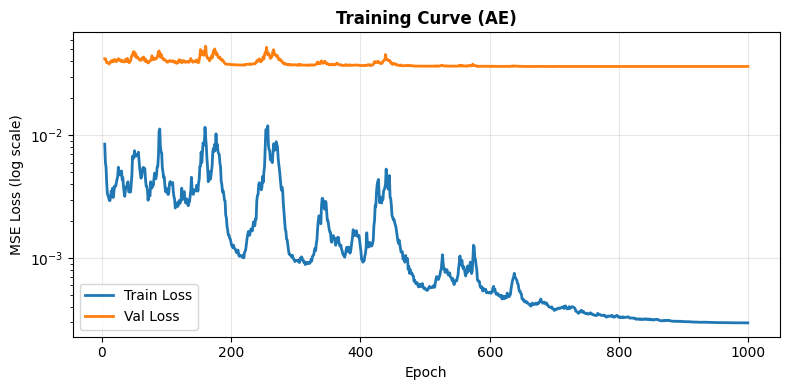

Saved training curve: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w724_s10\AE\AE_100dim_cholesky_02_\loss_curve.png


In [9]:
resume_state_dict = None
resume_initial_val = None
resume_source_path = None
# Resume logic: load checkpoint, check compatibility, extract state dict and initial val loss if available
if RESUME_TRAINING:
    if RESUME_MODEL_PATH is None:
        raise ValueError('RESUME_TRAINING=True but RESUME_MODEL_PATH is None.')

    resume_source_path = Path(RESUME_MODEL_PATH)
    if not resume_source_path.is_absolute():
        if IS_COLAB:
            resume_source_path = Path('/content/drive/MyDrive') / resume_source_path
        else:
            resume_source_path = project_root / resume_source_path
    resume_source_path = resume_source_path.resolve()

    if not resume_source_path.exists():
        raise FileNotFoundError(f'Checkpoint not found: {resume_source_path}')

    checkpoint = torch.load(resume_source_path, map_location=device)
    state_dict = checkpoint['model_state_dict'] if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint else checkpoint
    

    probe_model = AutoEncoder(
        input_dim=x_train.shape[1],
        latent_dim=LATENT_DIM,
        hidden_dims=HIDDEN_DIMS,
    )
    current_shapes = {k: tuple(v.shape) for k, v in probe_model.state_dict().items()}
    loaded_shapes = {k: tuple(v.shape) for k, v in state_dict.items()}

    missing_keys = [k for k in current_shapes.keys() if k not in loaded_shapes]
    unexpected_keys = [k for k in loaded_shapes.keys() if k not in current_shapes]
    shape_mismatches = [
        (k, loaded_shapes[k], current_shapes[k])
        for k in current_shapes.keys()
        if k in loaded_shapes and loaded_shapes[k] != current_shapes[k]
    ]

    if missing_keys or shape_mismatches or unexpected_keys:
        suggested_hidden = []
        # Cerchiamo tutti i pesi dei layer lineari nell'encoder
        for key, weight in state_dict.items():
            if key.startswith('encoder.') and key.endswith('.weight'):
                # Escludiamo il primo strato (input_dim -> hidden[0])
                # Se il peso ha come input input_dim, e il primo layer, lo saltiamo
                if weight.shape[1] == x_train.shape[1]:
                    continue
                suggested_hidden.append(int(weight.shape[0]))

        # L'ultimo elemento trovato sara il latent_dim
        if suggested_hidden:
            ckpt_latent_dim = suggested_hidden[-1]
            ckpt_hidden_dims = suggested_hidden[:-1]
            hint = (
                f'Checkpoint expects latent_dim={ckpt_latent_dim}, '
                f'hidden_dims={ckpt_hidden_dims}. '
                'Set these values to match before resuming, or start a new run without resume.',
            )
        else:
            hint = 'Checkpoint architecture could not be inferred. Use a checkpoint saved with the same model architecture.'

        details = []
        if missing_keys:
            details.append(f'Missing keys (first 5): {missing_keys[:5]}')
        if unexpected_keys:
            details.append(f'Unexpected keys (first 5): {unexpected_keys[:5]}')
        if shape_mismatches:
            k, loaded_shape, current_shape = shape_mismatches[0]
            details.append(f'Shape mismatch example: {k} loaded={loaded_shape}, current={current_shape}')

        raise RuntimeError(
            'Incompatible checkpoint for current AutoEncoder architecture. ' + hint + (' | ' + ' ; '.join(details) if details else '')
        )

    resume_state_dict = state_dict
    if isinstance(checkpoint, dict) and 'best_val_loss' in checkpoint:
        resume_initial_val = float(checkpoint['best_val_loss'])

    if resume_initial_val is None:
        temp_model = AutoEncoder(
            input_dim=x_train.shape[1],
            latent_dim=LATENT_DIM,
            hidden_dims=HIDDEN_DIMS,
        ).to(device)
        temp_model.load_state_dict(resume_state_dict)
        temp_model.eval()

        val_loader = DataLoader(TensorDataset(x_val), batch_size=BATCH_SIZE, shuffle=False)
        criterion = nn.MSELoss()
        val_loss_sum = 0.0
        with torch.no_grad():
            for (xb,) in val_loader:
                xb = xb.to(device)
                pred = temp_model(xb)
                loss = criterion(pred, xb)
                val_loss_sum += loss.item() * xb.size(0)
        resume_initial_val = val_loss_sum / len(val_loader.dataset)

    print(f'Loaded checkpoint: {resume_source_path}')
    print(f'Checkpoint validation MSE (baseline for resume): {resume_initial_val:.6f}')






 # Train the model (or resume training if applicable)
model, history, best_val = train_AE(
    x_train_tensor=x_train,
    x_val_tensor=x_val,
    latent_dim=LATENT_DIM,
    hidden_dims=HIDDEN_DIMS,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    dropout=DROPOUT,
    seed=SEED,
    scheduler_name=SCHEDULER_NAME,
    cosine_t_max=COSINE_T_MAX,
    cosine_eta_min=COSINE_ETA_MIN,
    resume_state_dict=resume_state_dict,
    initial_best_val=resume_initial_val,
 )


best_model_path = run_output_dir / 'best_model.pt'
torch.save(
    {
        'model_state_dict': model.state_dict(),
        'model_config': {
            'input_dim': int(x_train.shape[1]),
            'latent_dim': int(LATENT_DIM),
            'hidden_dims': HIDDEN_DIMS,
            'epochs': int(EPOCHS),
            'batch_size': int(BATCH_SIZE),
            'lr': float(LR),
            'weight_decay': float(WEIGHT_DECAY),
            'seed': int(SEED),
            'scheduler': {
                'key': str(SCHEDULER_NAME).strip().lower(),
            },
        },
        'best_val_loss': float(best_val),
    },
    best_model_path,
 )
print(f'Saved best model: {best_model_path}')
print(f'Best validation loss: {best_val:.6f}')


total_epochs = len(history['train_loss'])
if total_epochs == 0:
    print('No training history to plot.')
else:
    start_idx = 5 if total_epochs > 5 else 0
    epochs_to_plot = list(range(start_idx, total_epochs))
    train_vals = history['train_loss'][start_idx:]
    val_vals = history['val_loss'][start_idx:]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(epochs_to_plot, train_vals, label='Train Loss', linewidth=2)
    ax.plot(epochs_to_plot, val_vals, label='Val Loss', linewidth=2)
    ax.set_title('Training Curve (AE)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_yscale('log')
    ax.set_ylabel('MSE Loss (log scale)')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()

    train_curve_path = run_output_dir / 'loss_curve.png'
    fig.savefig(train_curve_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved training curve: {train_curve_path}')


In [10]:
print(model)

AutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=65703, out_features=2048, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Dropout(p=0, inplace=False)
    (3): Linear(in_features=2048, out_features=1024, bias=True)
    (4): LeakyReLU(negative_slope=0.01)
    (5): Dropout(p=0, inplace=False)
    (6): Linear(in_features=1024, out_features=512, bias=True)
    (7): LeakyReLU(negative_slope=0.01)
    (8): Dropout(p=0, inplace=False)
    (9): Linear(in_features=512, out_features=100, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=100, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=512, out_features=1024, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=1024, out_features=2048, bias=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Linear(in_features=2048, out_features=65703, bias=True)
  )
)


## Step 6: Matrix-Level Reconstruction Visualization
Show the same reconstruction plots used in the PCA notebook: clustered heatmaps and standard heatmaps (original, reconstructed, error).

Original Matrix:
[[1.     0.1809 0.146  0.0234 0.1973]
 [0.1809 1.     0.2591 0.1597 0.3356]
 [0.146  0.2591 1.     0.0816 0.1628]
 [0.0234 0.1597 0.0816 1.     0.1173]
 [0.1973 0.3356 0.1628 0.1173 1.    ]]
Reconstructed Matrix:
[[1.     0.1659 0.1426 0.0178 0.19  ]
 [0.1659 1.     0.2388 0.1504 0.3246]
 [0.1426 0.2388 1.     0.0835 0.1553]
 [0.0178 0.1504 0.0835 1.     0.1047]
 [0.19   0.3246 0.1553 0.1047 1.    ]]
Error Matrix:
[[ 0.     -0.015  -0.0034 -0.0056 -0.0073]
 [-0.015   0.     -0.0203 -0.0094 -0.011 ]
 [-0.0034 -0.0203  0.      0.0019 -0.0075]
 [-0.0056 -0.0094  0.0019  0.     -0.0126]
 [-0.0073 -0.011  -0.0075 -0.0126  0.    ]]

Sample index: 0
MSE: 0.000082 | MAE: 0.006924 | Frobenius: 3.279910
Error range - Min: -0.102989 | Max: 0.041968


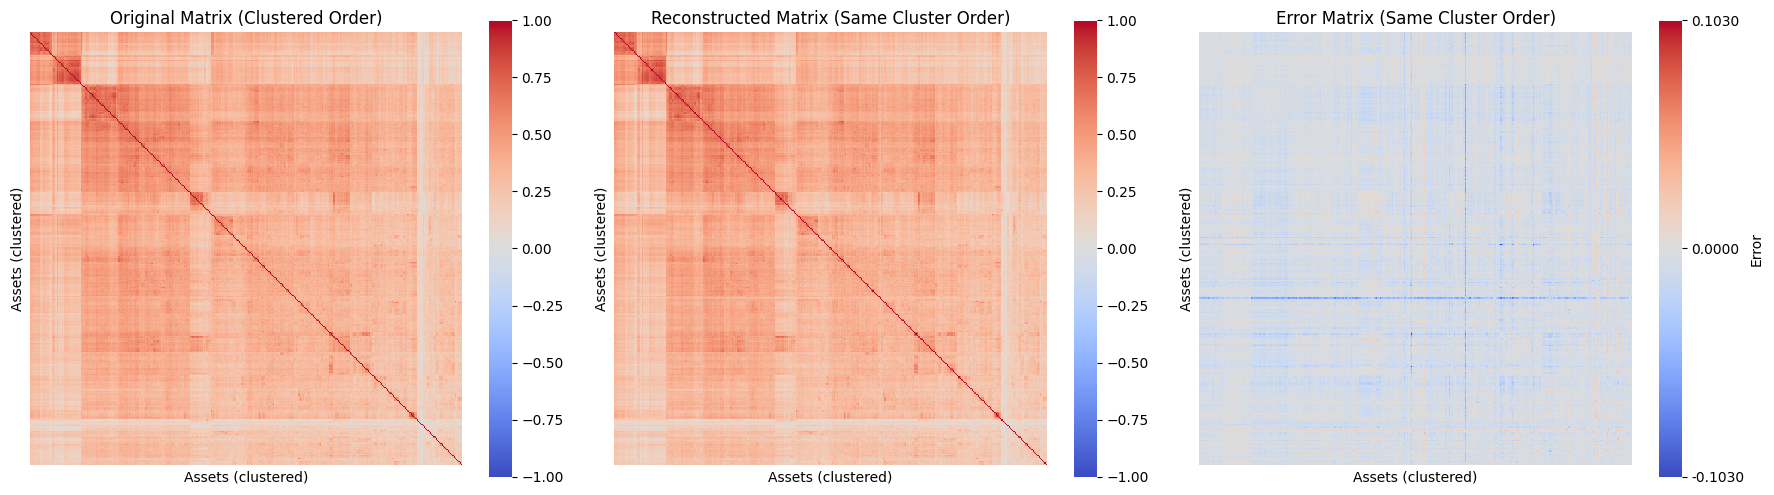

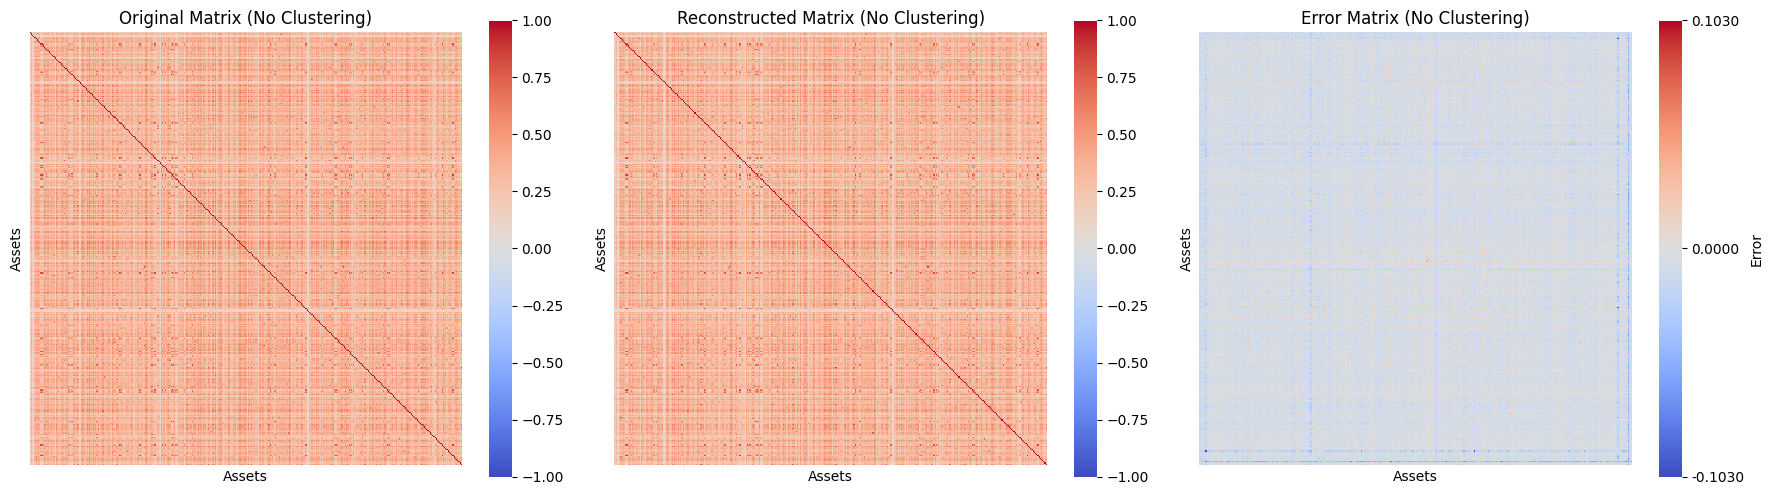

Saved heatmaps for matrix index 0:
 - C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w724_s10\AE\AE_100dim_cholesky_02_\heatmaps\idx0\clustered_heatmaps.png
 - C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w724_s10\AE\AE_100dim_cholesky_02_\heatmaps\idx0\standard_heatmaps.png


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ricostruzione
recon_out = reconstruct_matrices(model, x_test, n_assets=n_assets, train_mean=train_mean, train_std=train_std, batch_size=BATCH_SIZE)
recon_corr = recon_out['recon_corr']

SAMPLE_IDX = 0

# --- MODIFICA: Assicuriamoci di confrontare con la matrice di correlazione ORIGINALE ---
# test_corr è il tensore originale delle correlazioni del test set (n_test, 362, 362)
# test_chol è quello che la rete ha mangiato, ma noi vogliamo confrontare l'output con test_corr
test_corr_np = test_corr.numpy().astype(np.float32)

if not (0 <= SAMPLE_IDX < test_corr_np.shape[0]):
    raise ValueError(f'SAMPLE_IDX must be in [0, {test_corr_np.shape[0] - 1}]')

orig_mat = test_corr_np[SAMPLE_IDX]
# ------------------------------------------------------------------------------------

recon_mat = recon_corr[SAMPLE_IDX]
err_mat = recon_mat - orig_mat

print(f"Original Matrix:\n{orig_mat[:5, :5]}")  # Print the top-left 5x5 block
print(f"Reconstructed Matrix:\n{recon_mat[:5, :5]}")  
print(f"Error Matrix:\n{err_mat[:5, :5]}")  

mse_sample = float(np.mean((recon_mat - orig_mat) ** 2))
mae_sample = float(np.mean(np.abs(recon_mat - orig_mat)))
fro_sample = float(np.linalg.norm(recon_mat - orig_mat, ord='fro'))

print(f'\nSample index: {SAMPLE_IDX}')
print(f'MSE: {mse_sample:.6f} | MAE: {mae_sample:.6f} | Frobenius: {fro_sample:.6f}')
print(f'Error range - Min: {err_mat.min():.6f} | Max: {err_mat.max():.6f}')

heatmap_base_dir = run_output_dir / 'heatmaps'
heatmap_base_dir.mkdir(parents=True, exist_ok=True)
heatmap_dir = heatmap_base_dir / f'idx{SAMPLE_IDX}'
heatmap_dir.mkdir(parents=True, exist_ok=True)

shared_cmap = 'coolwarm'
err_abs_max = float(np.max(np.abs(err_mat)))
if err_abs_max == 0:
    err_abs_max = 1e-6

# --- HEATMAP CLUSTERIZZATE ---
# Build a single cluster ordering from the original matrix and reuse it for all three panels.
cluster_ref = sns.clustermap(
    orig_mat,
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    linewidths=0,
    figsize=(8, 8),
    cbar_kws={'label': 'Correlation'},
)
row_order = cluster_ref.dendrogram_row.reordered_ind
col_order = cluster_ref.dendrogram_col.reordered_ind
plt.close(cluster_ref.fig)

orig_mat_clustered = orig_mat[np.ix_(row_order, col_order)]
recon_mat_clustered = recon_mat[np.ix_(row_order, col_order)]
err_mat_clustered = err_mat[np.ix_(row_order, col_order)]

fig_cluster, axes_cluster = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(
    orig_mat_clustered,
    ax=axes_cluster[0],
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    square=True,
)
axes_cluster[0].set_title('Original Matrix (Clustered Order)')

sns.heatmap(
    recon_mat_clustered,
    ax=axes_cluster[1],
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    square=True,
)
axes_cluster[1].set_title('Reconstructed Matrix (Same Cluster Order)')

hm_cluster_err = sns.heatmap(
    err_mat_clustered,
    ax=axes_cluster[2],
    vmin=-err_abs_max,
    vmax=err_abs_max,
    cmap=shared_cmap,
    center=0,
    square=True,
    cbar_kws={'label': 'Error'},
)
axes_cluster[2].set_title('Error Matrix (Same Cluster Order)')

cbar_cluster = hm_cluster_err.collections[0].colorbar
cbar_cluster.set_ticks([-err_abs_max, 0, err_abs_max])
cbar_cluster.set_ticklabels([f'{-err_abs_max:.4f}', '0.0000', f'{err_abs_max:.4f}'])

for ax in axes_cluster:
    ax.set_xlabel('Assets (clustered)')
    ax.set_ylabel('Assets (clustered)')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
path_cluster_all = heatmap_dir / 'clustered_heatmaps.png'
fig_cluster.savefig(path_cluster_all, dpi=150, bbox_inches='tight')
plt.show()

# --- HEATMAP STANDARD ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(orig_mat, ax=axes[0], vmin=-1, vmax=1, cmap=shared_cmap, square=True)
axes[0].set_title('Original Matrix (No Clustering)')

sns.heatmap(recon_mat, ax=axes[1], vmin=-1, vmax=1, cmap=shared_cmap, square=True)
axes[1].set_title('Reconstructed Matrix (No Clustering)')

hm = sns.heatmap(
    err_mat,
    ax=axes[2],
    vmin=-err_abs_max,
    vmax=err_abs_max,
    cmap=shared_cmap,
    center=0,
    square=True,
    cbar_kws={'label': 'Error'},
)
axes[2].set_title('Error Matrix (No Clustering)')

cbar_std = hm.collections[0].colorbar
cbar_std.set_ticks([-err_abs_max, 0, err_abs_max])
cbar_std.set_ticklabels([f'{-err_abs_max:.4f}', '0.0000', f'{err_abs_max:.4f}'])

for ax in axes:
    ax.set_xlabel('Assets')
    ax.set_ylabel('Assets')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
path_standard = heatmap_dir / 'standard_heatmaps.png'
fig.savefig(path_standard, dpi=150, bbox_inches='tight')
plt.show()

print(f'Saved heatmaps for matrix index {SAMPLE_IDX}:')
print(f' - {path_cluster_all}')
print(f' - {path_standard}')

## Step 7: Reconstruction Error Statistics
Compute error statistics on train/test for both reconstructed matrices and Cholesky input vectors.

In [12]:
# --- 1. PREPARAZIONE DELLE MATRICI ORIGINALI ---
# Assicuriamoci di usare i tensori di CORRELAZIONE, non quelli di Cholesky
train_corr_np = train_corr.numpy().astype(np.float32)
val_corr_np = val_corr.numpy().astype(np.float32)
test_corr_np = test_corr.numpy().astype(np.float32)

# --- 2. RICOSTRUZIONE CON IL MODELLO ---
recon_out_train = reconstruct_matrices(model, x_train, n_assets=n_assets, train_mean=train_mean, train_std=train_std, batch_size=BATCH_SIZE)
recon_corr_train = recon_out_train['recon_corr']

recon_out_val = reconstruct_matrices(model, x_val, n_assets=n_assets, train_mean=train_mean, train_std=train_std, batch_size=BATCH_SIZE)
recon_corr_val = recon_out_val['recon_corr']

recon_out_test = reconstruct_matrices(model, x_test, n_assets=n_assets, train_mean=train_mean, train_std=train_std, batch_size=BATCH_SIZE)
recon_corr_test = recon_out_test['recon_corr']

# --- 3. CALCOLO DEGLI ERRORI ---
# Ora confrontiamo rigorosamente Correlazione vs Correlazione
errors_df_train_matrix, errors_stats_train_matrix = reconstruction_errors(train_corr_np, recon_corr_train)
errors_df_val_matrix, errors_stats_val_matrix = reconstruction_errors(val_corr_np, recon_corr_val)
errors_df_test_matrix, errors_stats_test_matrix = reconstruction_errors(test_corr_np, recon_corr_test)

# --- 4. VISUALIZZAZIONE RISULTATI ---
print('Reconstruction error statistics (Train Set, matrices):')
display(errors_stats_train_matrix)

print('\nReconstruction error statistics (Validation Set, matrices):')
display(errors_stats_val_matrix)

print('\nReconstruction error statistics (Test Set, matrices):')
display(errors_stats_test_matrix)

Reconstruction error statistics (Train Set, matrices):


,mean,std,min,median,max
MSE,8.827329e-07,0.000002,2.669457e-08,3.184632e-07,0.000025
MAE,5.022085e-04,0.000304,1.260221e-04,4.241921e-04,0.001812
Frobenius,2.613455e-01,0.218038,5.914527e-02,2.042849e-01,1.823554



Reconstruction error statistics (Validation Set, matrices):


,mean,std,min,median,max
MSE,0.000085,0.000137,0.000004,0.000038,0.000787
MAE,0.005556,0.004231,0.001331,0.004279,0.021048
Frobenius,2.787686,1.848840,0.706626,2.224754,10.153649



Reconstruction error statistics (Test Set, matrices):


,mean,std,min,median,max
MSE,0.000073,0.000081,0.000002,0.000062,0.000464
MAE,0.005113,0.002742,0.001058,0.005394,0.016111
Frobenius,2.750059,1.451076,0.569279,2.852412,7.800651


In [13]:
results_path = run_output_dir / 'run_results.json'

recon_stats_payload = None
if 'errors_stats_test_matrix' in globals():
    recon_stats_payload = {
        'train_matrix': errors_stats_train_matrix.astype(float).to_dict(orient='index'),
        'val_matrix': errors_stats_val_matrix.astype(float).to_dict(orient='index'),
        'test_matrix': errors_stats_test_matrix.astype(float).to_dict(orient='index'),
    }

scheduler_key = str(SCHEDULER_NAME).strip().lower()

if scheduler_key == 'none':
    scheduler_payload = None
elif scheduler_key == 'cosine':
    scheduler_payload = {
        'key': scheduler_key,
        'T_max': int(COSINE_T_MAX),
        'eta_min': float(COSINE_ETA_MIN),
    }

resumed = bool(RESUME_TRAINING)
if resumed:
    resume_info = {
        'source_model_path': str(resume_source_path) if resume_source_path is not None else None,
        'initial_best_val': float(resume_initial_val) if resume_initial_val is not None else None,
    }
else:
    resume_info = None

if MODEL_TYPE == 'linearAE':
    dropout_info = None
    hidden_dims_info = None
elif MODEL_TYPE == "AE":
    dropout_info = float(DROPOUT)
    hidden_dims_info = [int(x) for x in HIDDEN_DIMS]

results_payload = {
    'run': RUN,
    'seed': int(SEED),
    'dataset_info': {
        'dataset_name': DATASET_NAME,
        # --- MODIFICA: Aggiunta metadati espliciti sul formato dati ---
        'input_format': 'cholesky_lower_triangle_with_diag',
        'cholesky_jitter': 1e-6, 
        # --------------------------------------------------------------
        'n_matrices': int(n_matrices),
        'n_assets': int(n_assets),
        'n_features': int(n_features),
        'splits': {
            'train_size': int(n_train),
            'val_size': int(n_val),
            'test_size': int(n_test),
            'val_fraction': round(float(VAL_FRACTION), 2),
            'test_fraction': round(float(TEST_FRACTION), 2),
        },
    },
    'model': {
        'model_type': MODEL_TYPE,
        'latent_dim': int(LATENT_DIM),
        'hidden_dims': hidden_dims_info,
        'epochs': int(EPOCHS),
        'batch_size': int(BATCH_SIZE),
        'lr': float(LR),
        'weight_decay': float(WEIGHT_DECAY),
        'dropout': dropout_info,
        'scheduler': scheduler_payload,
        'best_val_loss': float(best_val) if 'best_val' in globals() else None,
        'resume': resume_info,
    },
    'artifacts': {
        'best_model_path': str(best_model_path) if 'best_model_path' in globals() else None,
        'training_curve_path': str(train_curve_path) if 'train_curve_path' in globals() else None,
    },
    'metrics': {
        'reconstruction_stats': recon_stats_payload,
    },
    'loss_history': {
        'train_loss': [float(x) for x in history['train_loss']],
        'val_loss': [float(x) for x in history['val_loss']],
        'lr': [float(x) for x in history['lr']] if 'lr' in history else None,
    },
}

with open(results_path, 'w', encoding='utf-8') as f:
    json.dump(results_payload, f, indent=4)

print(f'Saved results: {results_path}')

# 1. Assicurati che siano tensori PyTorch 
mean_tensor = train_mean if isinstance(train_mean, torch.Tensor) else torch.from_numpy(train_mean)
std_tensor = train_std if isinstance(train_std, torch.Tensor) else torch.from_numpy(train_std)

# 2. Definisci i percorsi dei file
mean_path = Path(run_output_dir, 'train_mean.pt')
std_path = Path(run_output_dir, 'train_std.pt')

# 3. Salva i file su disco
torch.save(mean_tensor, mean_path)
torch.save(std_tensor, std_path)

print(f"\n--- Salvataggio Statistiche (.pt) ---")
print(f"Media salvata in: {mean_path}")
print(f"Deviazione standard salvata in: {std_path}")

Saved results: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w724_s10\AE\AE_100dim_cholesky_02_\run_results.json

--- Salvataggio Statistiche (.pt) ---
Media salvata in: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w724_s10\AE\AE_100dim_cholesky_02_\train_mean.pt
Deviazione standard salvata in: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w724_s10\AE\AE_100dim_cholesky_02_\train_std.pt


In [14]:
def verify_psd_batch(matrices: np.ndarray, threshold: float = -1e-6):
    """
    Verifica se un batch di matrici è Semidefinito Positivo.
    Restituisce un boolean array e il numero di violazioni totali.
    """
    n_matrices = matrices.shape[0]
    is_psd = np.zeros(n_matrices, dtype=bool)
    
    # Calcoliamo solo gli autovalori per efficienza
    # np.linalg.eigvalsh è ottimizzato per matrici simmetriche
    all_evals = np.linalg.eigvalsh(matrices)
    
    # Verifica: tutti gli autovalori devono essere >= threshold
    is_psd = np.all(all_evals >= threshold, axis=1)
    
    return is_psd, all_evals

print(f"--- Verifica PSD sul Test Set ({recon_corr_test.shape[0]} matrici) ---")

# Eseguiamo la verifica
is_psd_mask, all_evals = verify_psd_batch(recon_corr_test)

total_psd = np.sum(is_psd_mask)
total_matrices = recon_corr_test.shape[0]
psd_ratio = (total_psd / total_matrices) * 100

print(f"Matrici verificate: {total_matrices}")
print(f"Matrici risultate PSD: {total_psd}")
print(f"Percentuale di successo: {psd_ratio:.2f}%")

if total_psd < total_matrices:
    print("\nAVVISO: Alcune matrici non hanno superato il test PSD.")
    # Analizziamo l'entità del problema
    min_evals = np.min(all_evals, axis=1)
    failures = min_evals[~is_psd_mask]
    print(f"Violazioni riscontrate (autovalore minimo): {failures}")
    print("Possibile causa: instabilità numerica o necessità di un JITTER maggiore nel pre-processing.")
else:
    print("\nSUCCESSO: Tutte le matrici ricostruite sono matematicamente PSD.")

--- Verifica PSD sul Test Set (42 matrici) ---
Matrici verificate: 42
Matrici risultate PSD: 42
Percentuale di successo: 100.00%

SUCCESSO: Tutte le matrici ricostruite sono matematicamente PSD.
